In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/AI/MushroomDataset/secondary_data.csv', sep=';')

In [4]:
# размер датасета, 61069 записей, 21 столбец
dataset.shape

(61069, 21)

In [5]:
dataset.head(10)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [7]:
dataset.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


In [8]:
dataset['class'].unique()

array(['p', 'e'], dtype=object)

In [9]:
dataset['class'].value_counts()

,count
class,
p,33888
e,27181


ВИЗУАЛИЗАЦИЯ

Для полной визуализации нужно перекодировать котигориальные признаки в числовые, и заполнить пропуски

In [10]:
dataset.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


In [11]:
cols_to_drop = ['veil-type', 'spore-print-color', 'stem-root', 'veil-color']
dataset = dataset.drop(cols_to_drop, axis=1)
print(f"Удалены колонки: {cols_to_drop}")

Удалены колонки: ['veil-type', 'spore-print-color', 'stem-root', 'veil-color']


In [12]:
dataset.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


In [13]:
dataset['stem-surface'].describe()

,stem-surface
count,22945
unique,8
top,s
freq,6025


In [14]:
dataset['stem-surface'].sort_values().unique()

array(['f', 'g', 'h', 'i', 'k', 's', 't', 'y', nan], dtype=object)

In [15]:
dataset['stem-surface_missing'] = dataset['stem-surface'].isnull().astype(int)
dataset['stem-surface'] = dataset['stem-surface'].fillna('Unknown')

In [16]:
dataset['gill-spacing'].describe()

,gill-spacing
count,36006
unique,3
top,c
freq,24710


In [17]:
dataset['gill-spacing'].sort_values().unique()

array(['c', 'd', 'f', nan], dtype=object)

In [18]:
dataset['gill-spacing_missing'] = dataset['gill-spacing'].isnull().astype(int)
dataset['gill-spacing'] = dataset['gill-spacing'].fillna('Unknown')

In [19]:
dataset['gill-attachment'].describe()

,gill-attachment
count,51185
unique,7
top,a
freq,12698


In [20]:
dataset['gill-attachment'].sort_values().unique()

array(['a', 'd', 'e', 'f', 'p', 's', 'x', nan], dtype=object)

In [21]:
most_common = dataset['gill-attachment'].mode()[0]
dataset['gill-attachment'] = dataset['gill-attachment'].fillna(most_common)
print(f"Заполнено самым частым значением: '{most_common}'")

Заполнено самым частым значением: 'a'


In [22]:
dataset['cap-surface'].describe()

,cap-surface
count,46949
unique,11
top,t
freq,8196


In [23]:
dataset['cap-surface'].sort_values().unique()

array(['d', 'e', 'g', 'h', 'i', 'k', 'l', 's', 't', 'w', 'y', nan],
      dtype=object)

In [24]:
dataset['cap-surface_missing'] = dataset['cap-surface'].isnull().astype(int)
dataset['cap-surface'] = dataset['cap-surface'].fillna('Unknown')

In [25]:
dataset['ring-type'].describe()

,ring-type
count,58598
unique,8
top,f
freq,48361


In [26]:
dataset['ring-type'].sort_values().unique()

array(['e', 'f', 'g', 'l', 'm', 'p', 'r', 'z', nan], dtype=object)

In [27]:
most_common = dataset['ring-type'].mode()[0]
dataset['ring-type'] = dataset['ring-type'].fillna(most_common)
print(f"Заполнено самым частым значением: '{most_common}'")

Заполнено самым частым значением: 'f'


In [28]:
dataset.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,0
cap-color,0
does-bruise-or-bleed,0
gill-attachment,0
gill-spacing,0
gill-color,0
stem-height,0


In [29]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
cat_features = ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-surface', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']
dataset[cat_features] = enc.fit_transform(dataset[cat_features])
dataset.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-surface,stem-color,has-ring,ring-type,habitat,season,stem-surface_missing,gill-spacing_missing,cap-surface_missing
0,p,15.26,6.0,3.0,6.0,0.0,2.0,0.0,10.0,16.95,17.09,8.0,11.0,1.0,2.0,0.0,3.0,0,1,0
1,p,16.60,6.0,3.0,6.0,0.0,2.0,0.0,10.0,17.99,18.19,8.0,11.0,1.0,2.0,0.0,2.0,0,1,0
2,p,14.07,6.0,3.0,6.0,0.0,2.0,0.0,10.0,17.80,17.74,8.0,11.0,1.0,2.0,0.0,3.0,0,1,0
3,p,14.17,2.0,4.0,1.0,0.0,2.0,0.0,10.0,15.77,15.98,8.0,11.0,1.0,5.0,0.0,3.0,0,1,0
4,p,14.64,6.0,4.0,6.0,0.0,2.0,0.0,10.0,16.53,17.20,8.0,11.0,1.0,5.0,0.0,3.0,0,1,0


In [30]:
enc.categories_

[array(['b', 'c', 'f', 'o', 'p', 's', 'x'], dtype=object),
 array(['Unknown', 'd', 'e', 'g', 'h', 'i', 'k', 'l', 's', 't', 'w', 'y'],
       dtype=object),
 array(['b', 'e', 'g', 'k', 'l', 'n', 'o', 'p', 'r', 'u', 'w', 'y'],
       dtype=object),
 array(['f', 't'], dtype=object),
 array(['a', 'd', 'e', 'f', 'p', 's', 'x'], dtype=object),
 array(['Unknown', 'c', 'd', 'f'], dtype=object),
 array(['b', 'e', 'f', 'g', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y'],
       dtype=object),
 array(['Unknown', 'f', 'g', 'h', 'i', 'k', 's', 't', 'y'], dtype=object),
 array(['b', 'e', 'f', 'g', 'k', 'l', 'n', 'o', 'p', 'r', 'u', 'w', 'y'],
       dtype=object),
 array(['f', 't'], dtype=object),
 array(['e', 'f', 'g', 'l', 'm', 'p', 'r', 'z'], dtype=object),
 array(['d', 'g', 'h', 'l', 'm', 'p', 'u', 'w'], dtype=object),
 array(['a', 's', 'u', 'w'], dtype=object)]

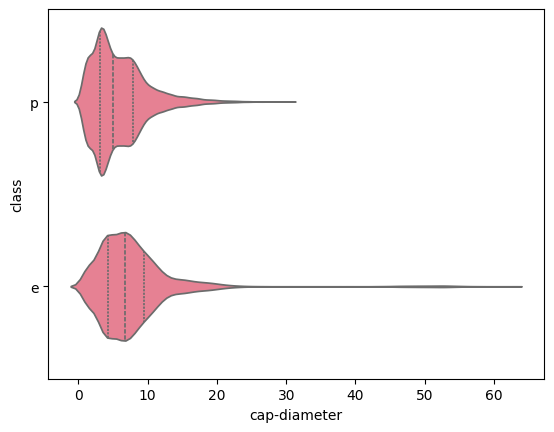

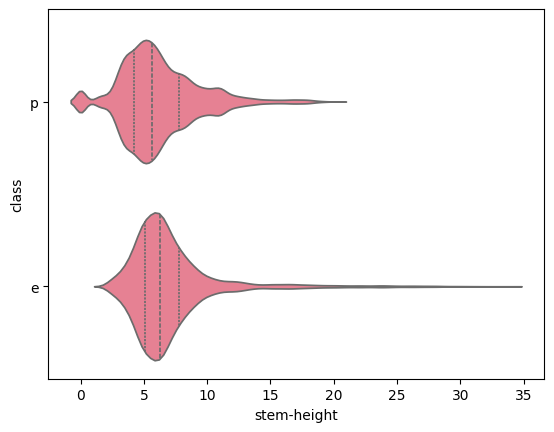

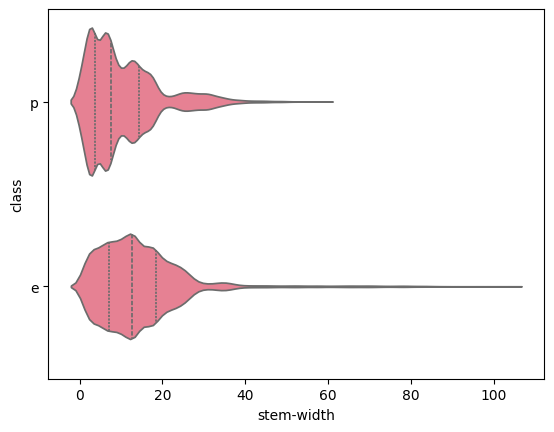

In [31]:
# рисуем графики только для числовых признаков (которые были числовыми до кодировки)
sns.violinplot(y='class', x='cap-diameter', data=dataset, inner='quartile')
plt.show()

sns.violinplot(y='class', x='stem-height', data=dataset, inner='quartile')
plt.show()

sns.violinplot(y='class', x='stem-width', data=dataset, inner='quartile')
plt.show()

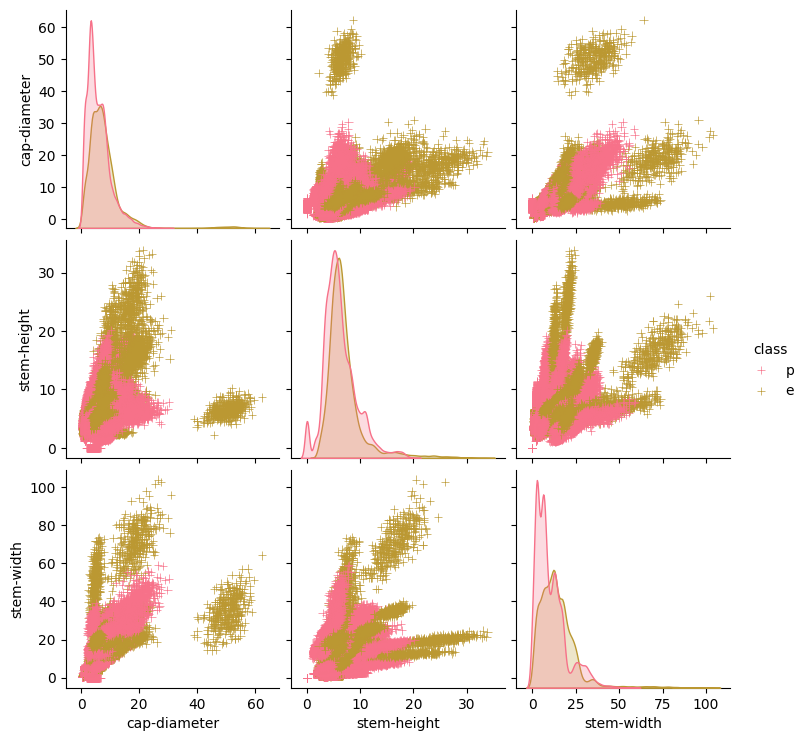

In [32]:
# только числовые признаки и целевая переменная
p = ['cap-diameter', 'stem-height', 'stem-width', 'class']

sns.pairplot(dataset[p], hue='class', markers='+')
plt.show()

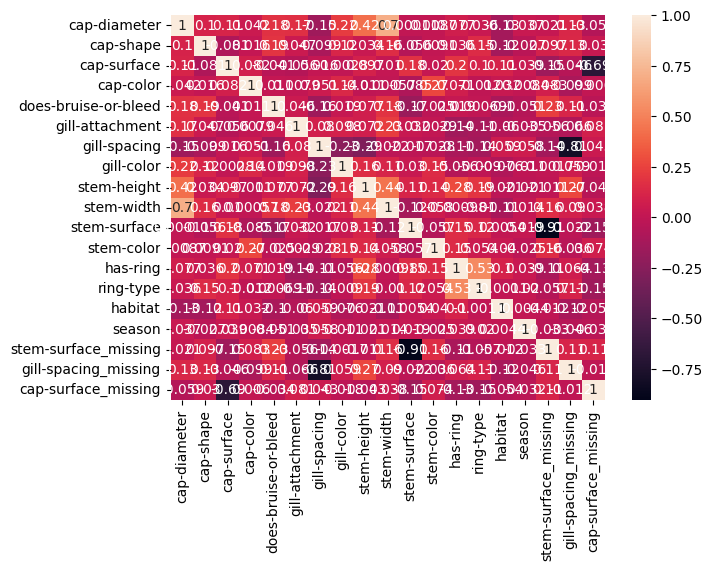

In [33]:
plt.figure(figsize=(7,5))
sns.heatmap(dataset.corr(numeric_only = True), annot=True)
plt.show()

ПОСТРОЕНИЕ МОДЕЛИ

Разделение набора данных

In [34]:
X = dataset.drop(['class'], axis=1)
y = dataset['class']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (61069, 19) | y shape: (61069,) 


Train Test разделение

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

In [36]:
import scipy.stats as stats

y_mapped = y.map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.30, shuffle=True)

stats.ttest_ind(a=y_train, b=y_test)

TtestResult(statistic=np.float64(0.13444031971485895), pvalue=np.float64(0.893054843542607), df=np.float64(61067.0))

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.20, random_state=15, stratify=y_mapped)

stats.ttest_ind(a=y_train, b=y_test)

TtestResult(statistic=np.float64(-0.0058831355023246995), pvalue=np.float64(0.9953059833085165), df=np.float64(61067.0))

Обучение и выбор оптимальной модели

In [43]:
# создаем лист для тех моделей, которые будем изучать
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
#models.append(('SVC', SVC(gamma='auto')))

# оцениваем их метрики
results = []
model_names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    model_names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.639484 (0.006887)
LDA: 0.640364 (0.007015)
KNN: 0.999181 (0.000399)
CART: 0.997196 (0.000854)
NB: 0.604953 (0.005607)


Лучшие метрики у SVC. Но она очень долго строится поэтому будем работать с KNN

Обучение конкретной модели

In [44]:
sk_knn = KNeighborsClassifier()
sk_knn.fit(X_train, y_train)
sk_knn_pred_res = sk_knn.predict(X_test)
sk_knn_accuracy = accuracy_score(y_test, sk_knn_pred_res)

print(f'sk KNN accuracy: {sk_knn_accuracy}')
print(f'sk KNN prediction: {sk_knn_pred_res}')

sk KNN accuracy: 0.9990175208776814
sk KNN prediction: [1 1 0 ... 1 1 0]


Визуализация решения

<Axes: title={'center': 'KNN surface with original features'}>

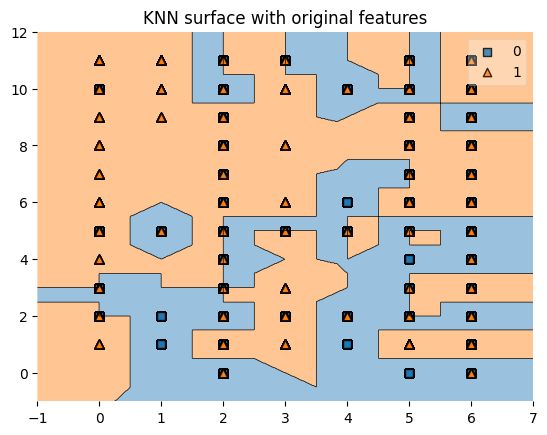

In [45]:
from mlxtend.plotting import plot_decision_regions

y_s = y_train
X_2d= X_train[['cap-shape',	'cap-color']].values

y_2d = y_s.values


sk_knn1 = KNeighborsClassifier()
sk_knn1.fit(X_2d, y_2d)

plt.title('KNN surface with original features')
plot_decision_regions(
    X=X_2d,
    y=y_2d,
    clf=sk_knn1)

у KNN нет transform, используем PCA

In [46]:
from sklearn.decomposition import PCA

<Axes: title={'center': 'KNN surface with PCA transformed features'}>

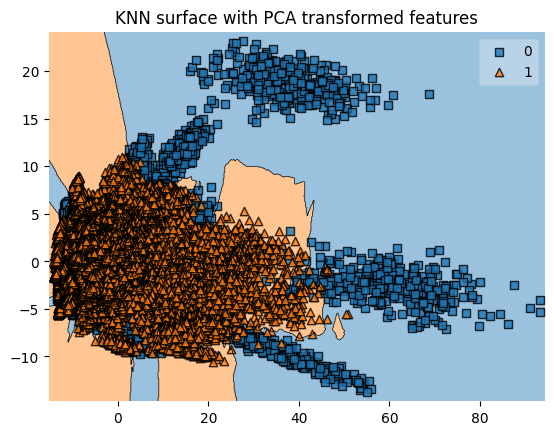

In [49]:
df = dataset["class"].map({'e': 0, 'p': 1})

X_all = dataset.drop('class', axis=1).values
ys = df.values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

X_pca_train, X_pca_test, y_train_pca, y_test_pca = train_test_split(X_pca, ys, random_state=0)

sk_knn2 = KNeighborsClassifier()
sk_knn2.fit(X_pca_train, y_train_pca)

plt.title('KNN surface with PCA transformed features')
plot_decision_regions(X=X_pca, y=ys, clf=sk_knn2)

In [50]:
predicted = sk_knn2.predict(X_pca_test)

In [56]:
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition

## Accuray e AUC
'''
Теперь смотрим метрики.
НА ТЕСТОВОМ ДАТАСЕТЕ
'''
accuracy = metrics.accuracy_score(y_test_pca, predicted)#Оценим точность классификации.

'''
Получим результат
'''

## Precision e Recall
recall = metrics.recall_score(y_test_pca, predicted, average="weighted")
precision = metrics.precision_score(y_test_pca, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test_pca, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.74
Precision (confidence when predicting a 1): 0.74
Detail:
              precision    recall  f1-score   support

           0       0.70      0.71      0.71      6679
           1       0.77      0.76      0.77      8589

    accuracy                           0.74     15268
   macro avg       0.74      0.74      0.74     15268
weighted avg       0.74      0.74      0.74     15268

